### Stock Market Exploratory Data Analysis
### Company: Infosys Ltd (INFY.NS)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [4]:
stock = yf.download("INFY.NS",start="2020-01-01",end="2025-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2020-01-01,619.740356,622.389739,616.123778,618.184403,2112415
2020-01-02,617.932007,623.062496,614.735962,621.464499,5658200
2020-01-03,627.436096,629.118230,617.259204,617.259204,7882938
2020-01-06,621.422424,633.996388,619.445937,627.520161,6519403
2020-01-07,612.212769,624.576414,609.857740,620.707526,7899363


In [5]:
stock.tail()

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2024-12-24,1814.903442,1846.228436,1749.258662,1832.015755,2360544
2024-12-26,1813.334839,1825.075764,1808.486373,1814.903491,3623321
2024-12-27,1822.223755,1829.258840,1810.007487,1815.236250,3937500
2024-12-30,1812.003906,1821.510747,1793.465566,1821.225496,7789055
2024-12-31,1787.286011,1803.447640,1754.059650,1798.979471,3613063


In [6]:
stock.shape

(1238, 5)

In [7]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1238 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, INFY.NS)   1238 non-null   float64
 1   (High, INFY.NS)    1238 non-null   float64
 2   (Low, INFY.NS)     1238 non-null   float64
 3   (Open, INFY.NS)    1238 non-null   float64
 4   (Volume, INFY.NS)  1238 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB


In [8]:
stock.isnull().sum()

Price   Ticker 
Close   INFY.NS    0
High    INFY.NS    0
Low     INFY.NS    0
Open    INFY.NS    0
Volume  INFY.NS    0
dtype: int64

In [9]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
count,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03
mean,1271.497490,1283.919559,1258.999786,1271.564476,7.520991e+06
std,325.315671,327.140328,323.030019,325.445496,5.208159e+06
min,442.779785,469.315411,428.313393,428.313393,3.719660e+05
25%,1143.311340,1151.379798,1132.024612,1142.875251,4.692584e+06
50%,1329.047180,1340.907371,1316.044321,1329.467203,6.272753e+06
75%,1481.541840,1497.485649,1467.240367,1482.356728,8.730180e+06
max,1901.083008,1907.500126,1880.072854,1897.042542,9.043211e+07


In [10]:
stock.describe(percentiles=[0.25,0.5,0.75,0.90,0.99])

Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
count,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03
mean,1271.497490,1283.919559,1258.999786,1271.564476,7.520991e+06
std,325.315671,327.140328,323.030019,325.445496,5.208159e+06
min,442.779785,469.315411,428.313393,428.313393,3.719660e+05
25%,1143.311340,1151.379798,1132.024612,1142.875251,4.692584e+06
50%,1329.047180,1340.907371,1316.044321,1329.467203,6.272753e+06
75%,1481.541840,1497.485649,1467.240367,1482.356728,8.730180e+06
90%,1658.534387,1673.345425,1637.793032,1659.645949,1.263631e+07
99%,1837.994480,1856.768199,1819.948647,1837.596447,2.648654e+07


In [11]:
stock["Daily Return"] = stock["Close"].pct_change()
stock.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS,
Date,,,,,,
2020-01-01,619.740356,622.389739,616.123778,618.184403,2112415,NaN
2020-01-02,617.932007,623.062496,614.735962,621.464499,5658200,-0.002918
2020-01-03,627.436096,629.118230,617.259204,617.259204,7882938,0.015380
2020-01-06,621.422424,633.996388,619.445937,627.520161,6519403,-0.009585
2020-01-07,612.212769,624.576414,609.857740,620.707526,7899363,-0.014820


In [12]:
stock["Daily Return"].describe()

count    1237.000000
mean        0.001010
std         0.017547
min        -0.100393
25%        -0.008364
50%         0.000910
75%         0.009984
max         0.120334
Name: Daily Return, dtype: float64

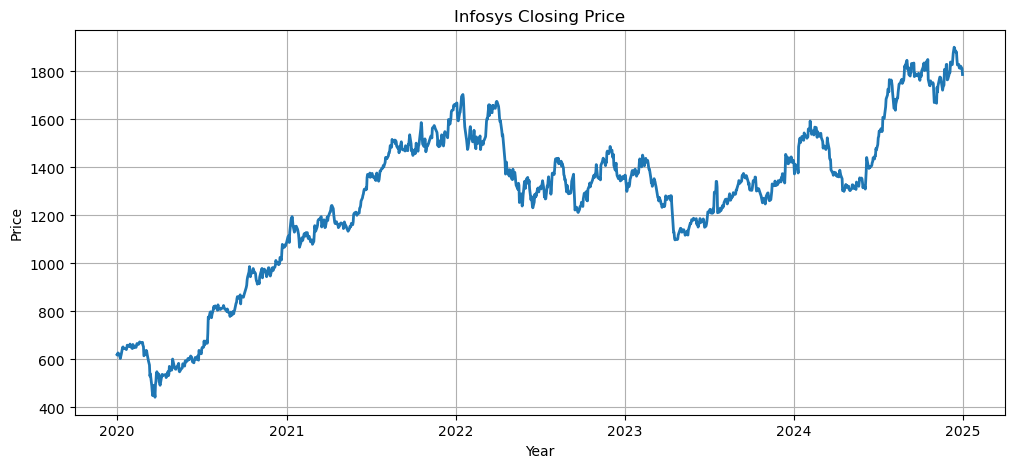

In [13]:
plt.figure(figsize=(12,5))

plt.plot(stock.index,stock["Close"],linewidth=2)
plt.title("Infosys Closing Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True)

plt.show()

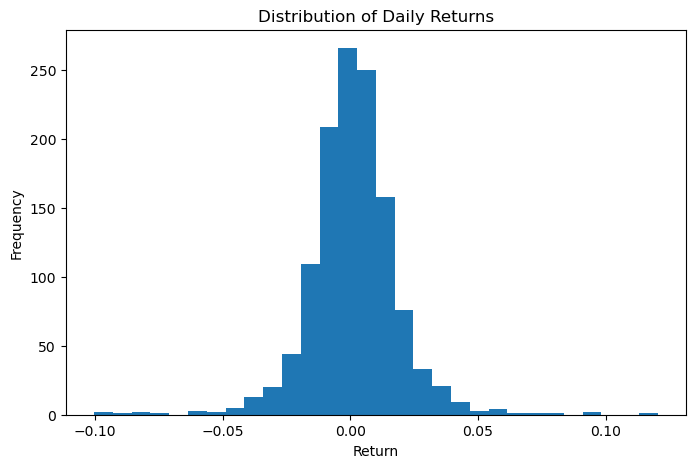

In [14]:
plt.figure(figsize=(8,5))

plt.hist(stock["Daily Return"].dropna(),bins=30)
plt.title("Distribution of Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.show()

In [15]:
stock[["Open","High","Low","Close","Volume"]].corr()

,Price,Open,High,Low,Close,Volume
,Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Price,Ticker,,,,,
Open,INFY.NS,1.000000,0.999408,0.999416,0.998807,-0.309977
High,INFY.NS,0.999408,1.000000,0.999375,0.999536,-0.299324
Low,INFY.NS,0.999416,0.999375,1.000000,0.999511,-0.316979
Close,INFY.NS,0.998807,0.999536,0.999511,1.000000,-0.307736
Volume,INFY.NS,-0.309977,-0.299324,-0.316979,-0.307736,1.000000


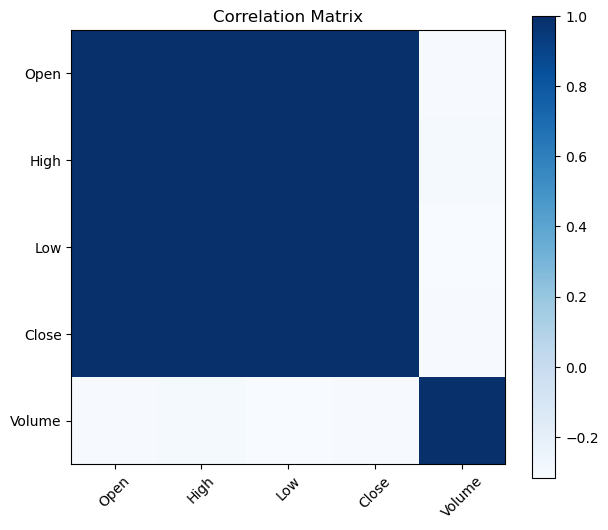

In [16]:
plt.figure(figsize=(7,6))

plt.imshow(stock[["Open","High","Low","Close","Volume"]].corr(),cmap="Blues")
plt.colorbar()
plt.xticks(range(5),["Open","High","Low","Close","Volume"],rotation=45)
plt.yticks(range(5),["Open","High","Low","Close","Volume"])
plt.title("Correlation Matrix")

plt.show()

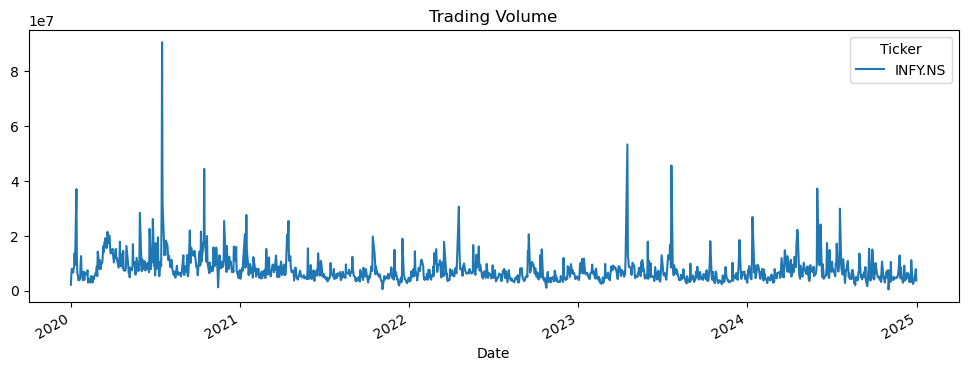

In [17]:
stock["Volume"].plot(figsize=(12,4),title="Trading Volume")
plt.show()